# ניסוי כניסה עמוקה יותר — מחברת החלטה

24 חלופות קפואות; נתונים יומיים; אין תקופת אימות שלא נצפתה. המחברת קוראת תוצאות שמורות ואינה מריצה וריאנטים חדשים.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
candidate_list=[Path.cwd(), *Path.cwd().parents]
study_candidate_list=[path_obj/suffix_str for path_obj in candidate_list for suffix_str in ('', 'results/research/mr_deeper_dip_entry_study')]
study_path=next((path_obj for path_obj in study_candidate_list if (path_obj/'tables/summary.csv').is_file()), None)
assert study_path is not None, 'Open this notebook in the study folder or its repository, with the tables and charts folders present.'
summary_df=pd.read_csv(study_path/'tables/summary.csv')
assert len(summary_df)==24
assert not summary_df.duplicated(['strategy','layer','policy']).any()
display(summary_df[['strategy','layer','policy','cagr','sharpe','max_drawdown','fills','orders','mean_exposure']])

,strategy,layer,policy,cagr,sharpe,max_drawdown,fills,orders,mean_exposure
0,dv2,central,moo,0.194869,0.978394,-0.308678,8067,8067,0.861546
1,dv2,central,limit_0.5pct,0.182263,0.950644,-0.283718,6966,9566,0.778525
2,dv2,central,limit_1pct,0.193496,1.043678,-0.271271,5809,11684,0.673043
3,dv2,central,limit_2pct,0.160527,0.964169,-0.218458,3767,16973,0.450155
4,dv2,stress,moo,0.083703,0.497348,-0.377932,8067,8067,0.861392
5,dv2,stress,limit_0.5pct,0.064325,0.416047,-0.390644,6850,9755,0.767694
6,dv2,stress,limit_1pct,0.087182,0.541602,-0.348232,5696,11911,0.663278
7,dv2,stress,limit_2pct,0.101751,0.654748,-0.284369,3687,17223,0.440910
8,hpi235,central,moo,0.160344,1.041908,-0.177130,4714,4719,0.718840
9,hpi235,central,limit_0.5pct,0.182829,1.217146,-0.170212,4075,5755,0.631010


## מחיר הכניסה מול ההזדמנויות שהוחמצו

הבדיקה המזווגת מחזיקה את כמויות הבסיס ואת היציאות קבועות. היא אבחון, ולא תיק נוסף.

In [2]:
display(pd.read_csv(study_path/'tables/paired_summary.csv'))
display(pd.read_csv(study_path/'tables/decision_summary.csv'))

,strategy,policy,opportunities,fills,fill_rate,closed_opportunities,terminal_opportunities,closed_delta_pnl,terminal_delta_pnl,baseline_pnl,limit_pnl,delta_pnl,mean_delta_per_opportunity,mean_baseline_return_all_opportunities,mean_limit_return_all_opportunities,net_fill_price_improvement,mean_limit_return_filled,mean_baseline_return_same_filled,missed_baseline_pnl,gross_fill_price_improvement
0,dv2,limit_0.5pct,8067,5870,0.727656,8057,10,8608.472483,26365.559736,1.841137e+06,1.876111e+06,34974.032218,4.335445,0.004022,0.003554,1.660864e+06,0.004884,-0.000117,1.625890e+06,1.660449e+06
1,dv2,limit_1pct,8067,4082,0.506012,8057,10,-196605.679627,37728.456899,1.841137e+06,1.682259e+06,-158877.222728,-19.694710,0.004022,0.002826,2.422119e+06,0.005585,-0.004417,2.580997e+06,2.421514e+06
2,dv2,limit_2pct,8067,1928,0.238998,8057,10,-828167.050173,45248.159727,1.841137e+06,1.058218e+06,-782918.890447,-97.052050,0.004022,0.001641,2.458909e+06,0.006866,-0.013139,3.241828e+06,2.458294e+06
3,hpi235,limit_0.5pct,4714,3344,0.709376,4704,10,-183602.543011,24014.374865,1.091053e+06,9.314647e+05,-159588.168145,-33.854087,0.005581,0.005040,6.931472e+05,0.007105,0.002104,8.527354e+05,6.929740e+05
4,hpi235,limit_1pct,4714,2212,0.469241,4704,10,-350365.697814,26968.959452,1.091053e+06,7.676561e+05,-323396.738362,-68.603466,0.005581,0.004048,9.330043e+05,0.008627,-0.001376,1.256401e+06,9.327711e+05
5,hpi235,limit_2pct,4714,1015,0.215316,4704,10,-574796.211396,27664.625349,1.091053e+06,5.439213e+05,-547131.586047,-116.065249,0.005581,0.002794,8.703393e+05,0.012976,-0.007029,1.417471e+06,8.701217e+05
6,sector,limit_0.5pct,943,552,0.585366,939,4,-75209.055801,1796.881528,2.255335e+05,1.521213e+05,-73412.174274,-77.849602,0.009459,0.006449,7.076444e+04,0.011017,0.006015,1.441766e+05,7.074676e+04
7,sector,limit_1pct,943,304,0.322375,939,4,-128999.133410,3628.280234,2.255335e+05,1.001626e+05,-125370.853176,-132.948943,0.009459,0.003855,7.868850e+04,0.011959,0.001956,2.040594e+05,7.866883e+04
8,sector,limit_2pct,943,86,0.091198,939,4,-200379.228519,4315.965164,2.255335e+05,2.947021e+04,-196063.263355,-207.914383,0.009459,0.001199,4.056629e+04,0.013147,-0.006858,2.366296e+05,4.055616e+04


,strategy,policy,central_delta,stress_delta,positive_periods
0,dv2,limit_0.5pct,-0.012606,-0.019379,2
1,dv2,limit_1pct,-0.001372,0.003479,2
2,dv2,limit_2pct,-0.034341,0.018048,0
3,hpi235,limit_0.5pct,0.022486,0.019505,3
4,hpi235,limit_1pct,0.005813,0.009748,2
5,hpi235,limit_2pct,-0.039843,-0.003355,0
6,sector,limit_0.5pct,-0.018674,-0.019224,0
7,sector,limit_1pct,-0.035129,-0.027018,0
8,sector,limit_2pct,-0.057786,-0.044383,0


## ביקורת, תקופות ועלויות

כל החשבונות נבדקים מתוך קובצי העסקאות. תיקון המובהקות מתייחס לתשע השוואות יומיות; אין אימות מחוץ למדגם.

In [3]:
assert summary_df['cash_error_max'].max()<1e-5
assert summary_df['trade_nav_error'].max()<1e-5
assert summary_df['daily_mark_error'].max()<1e-5
display(pd.read_csv(study_path/'tables/inference.csv'))
display(pd.read_csv(study_path/'tables/dv2_input_exposure_summary.csv'))
display(pd.read_csv(study_path/'tables/capacity_summary.csv'))
print(json.loads((study_path/'tables/accounting_audit.json').read_text()))

,strategy,policy,mean_daily_delta,annualized_arithmetic_delta,hac_t,p_two_sided,ci95_low_annual,ci95_high_annual,p_holm_9
0,dv2,limit_0.5pct,-0.000047,-0.011960,-0.874311,0.381949,-0.038769,0.014850,1.000000
1,dv2,limit_1pct,-0.000018,-0.004482,-0.229579,0.818419,-0.042744,0.033781,1.000000
2,dv2,limit_2pct,-0.000141,-0.035520,-1.267167,0.205096,-0.090460,0.019420,0.882077
3,hpi235,limit_0.5pct,0.000072,0.018089,1.351875,0.176415,-0.008137,0.044314,0.882077
4,hpi235,limit_1pct,0.000010,0.002622,0.146324,0.883666,-0.032493,0.037736,1.000000
5,hpi235,limit_2pct,-0.000158,-0.039746,-1.678657,0.093219,-0.086153,0.006661,0.559314
6,sector,limit_0.5pct,-0.000072,-0.018244,-2.967999,0.002997,-0.030292,-0.006196,0.020982
7,sector,limit_1pct,-0.000137,-0.034495,-3.703329,0.000213,-0.052751,-0.016239,0.001702
8,sector,limit_2pct,-0.000227,-0.057263,-4.408458,0.000010,-0.082721,-0.031804,0.000094


,layer,policy,selected,selected_prior200_native_only,filled_prior200_native_only,selected_unknown_reference,executions_native_only_ohlc,executions_without_exact_ohlc,forced_liquidations
0,central,moo,8067,8,8,0,0,1,1
1,central,limit_0.5pct,9566,12,9,0,0,0,0
2,central,limit_1pct,11684,12,7,0,0,0,0
3,central,limit_2pct,16973,18,6,0,0,0,0
4,stress,moo,8067,8,8,0,0,1,1
5,stress,limit_0.5pct,9755,12,9,0,0,0,0
6,stress,limit_1pct,11911,12,6,0,0,0,0
7,stress,limit_2pct,17223,18,6,0,0,0,0


,strategy,policy,p50,p90,p99,max,missing_adv,missing_request_notional
0,dv2,limit_0.5pct,0.000136,0.000454,0.001045,0.004570,0,0
1,dv2,limit_1pct,0.000142,0.000447,0.001027,0.005393,0,0
2,dv2,limit_2pct,0.000131,0.000378,0.000765,0.005477,0,0
3,dv2,moo,0.000159,0.000562,0.001280,0.007125,0,0
4,hpi235,limit_0.5pct,0.000137,0.000490,0.001264,0.007882,3,7
5,hpi235,limit_1pct,0.000139,0.000460,0.001091,0.006891,3,7
6,hpi235,limit_2pct,0.000095,0.000278,0.000592,0.003981,3,7
7,hpi235,moo,0.000108,0.000368,0.000934,0.005983,3,5
8,sector,limit_0.5pct,0.000033,0.000894,0.005069,0.008311,0,0
9,sector,limit_1pct,0.000027,0.000776,0.004469,0.008292,0,0


[{'strategy': 'dv2', 'native_transaction_parity': True, 'native_dividend_event_parity': True, 'dividend_events': 424}, {'strategy': 'hpi235', 'native_transaction_parity': True, 'native_dividend_event_parity': True, 'dividend_events': 390}, {'strategy': 'sector', 'native_transaction_parity': True, 'native_dividend_event_parity': True, 'dividend_events': 158}]


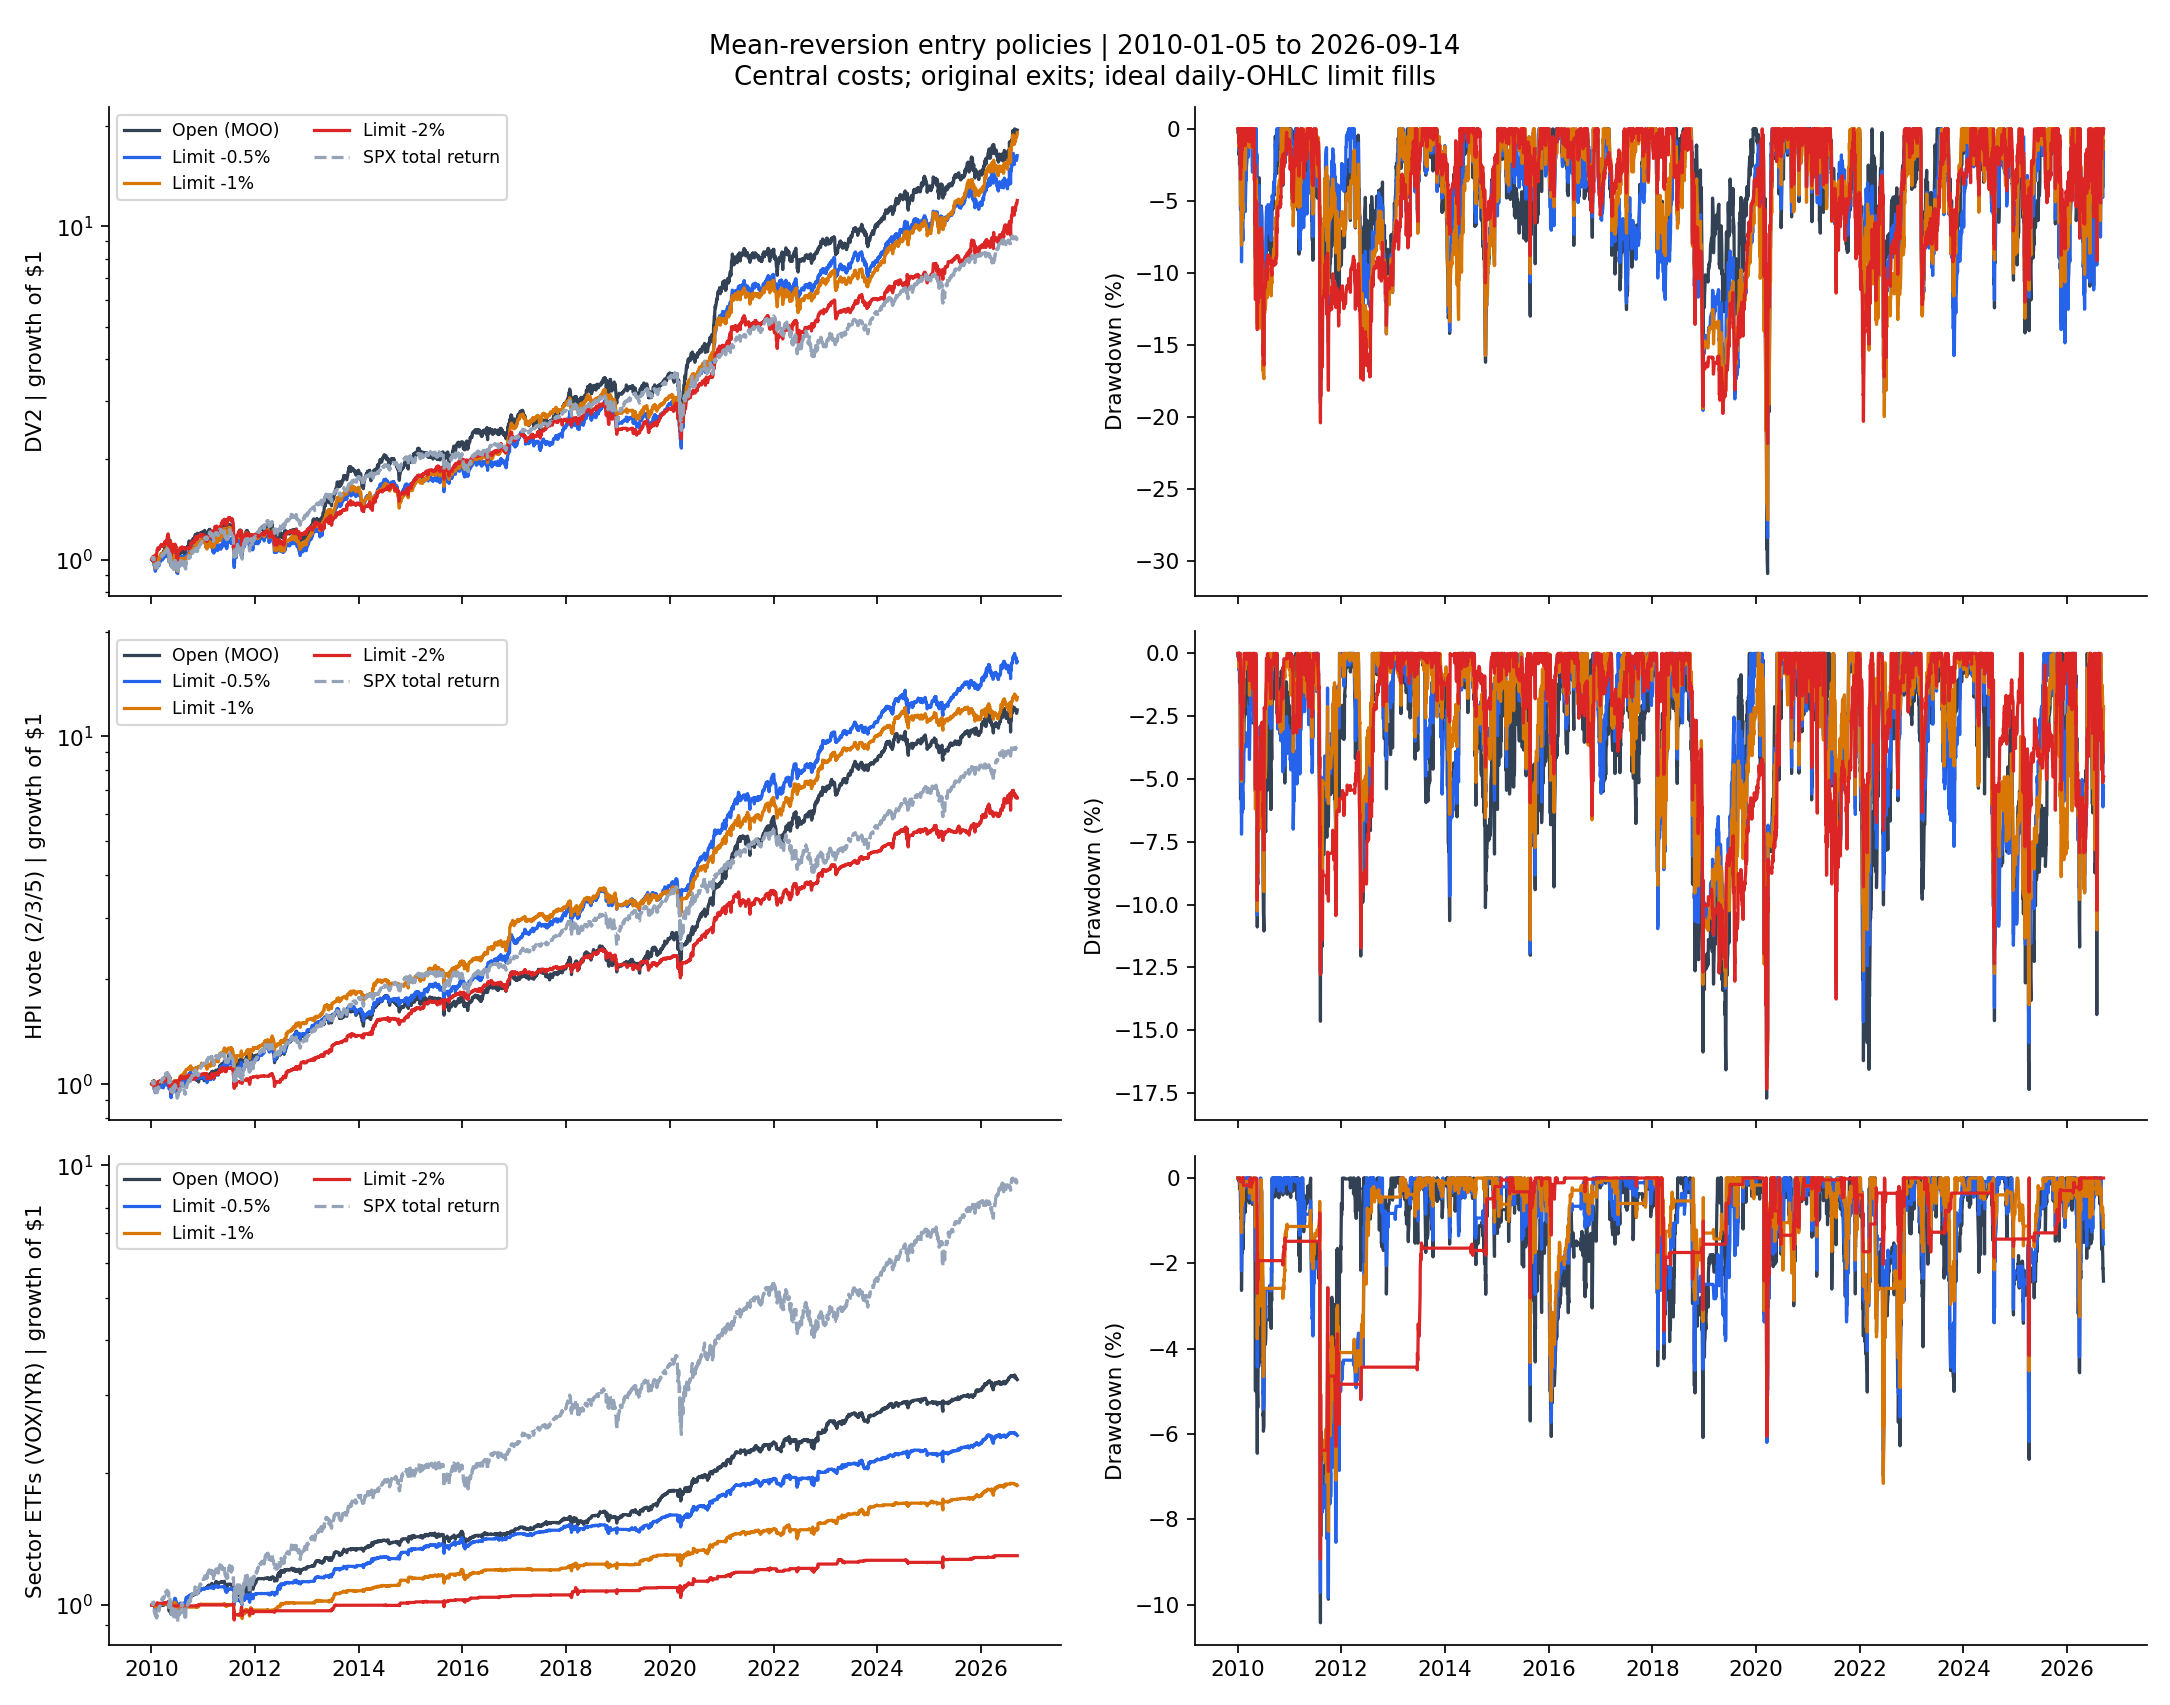

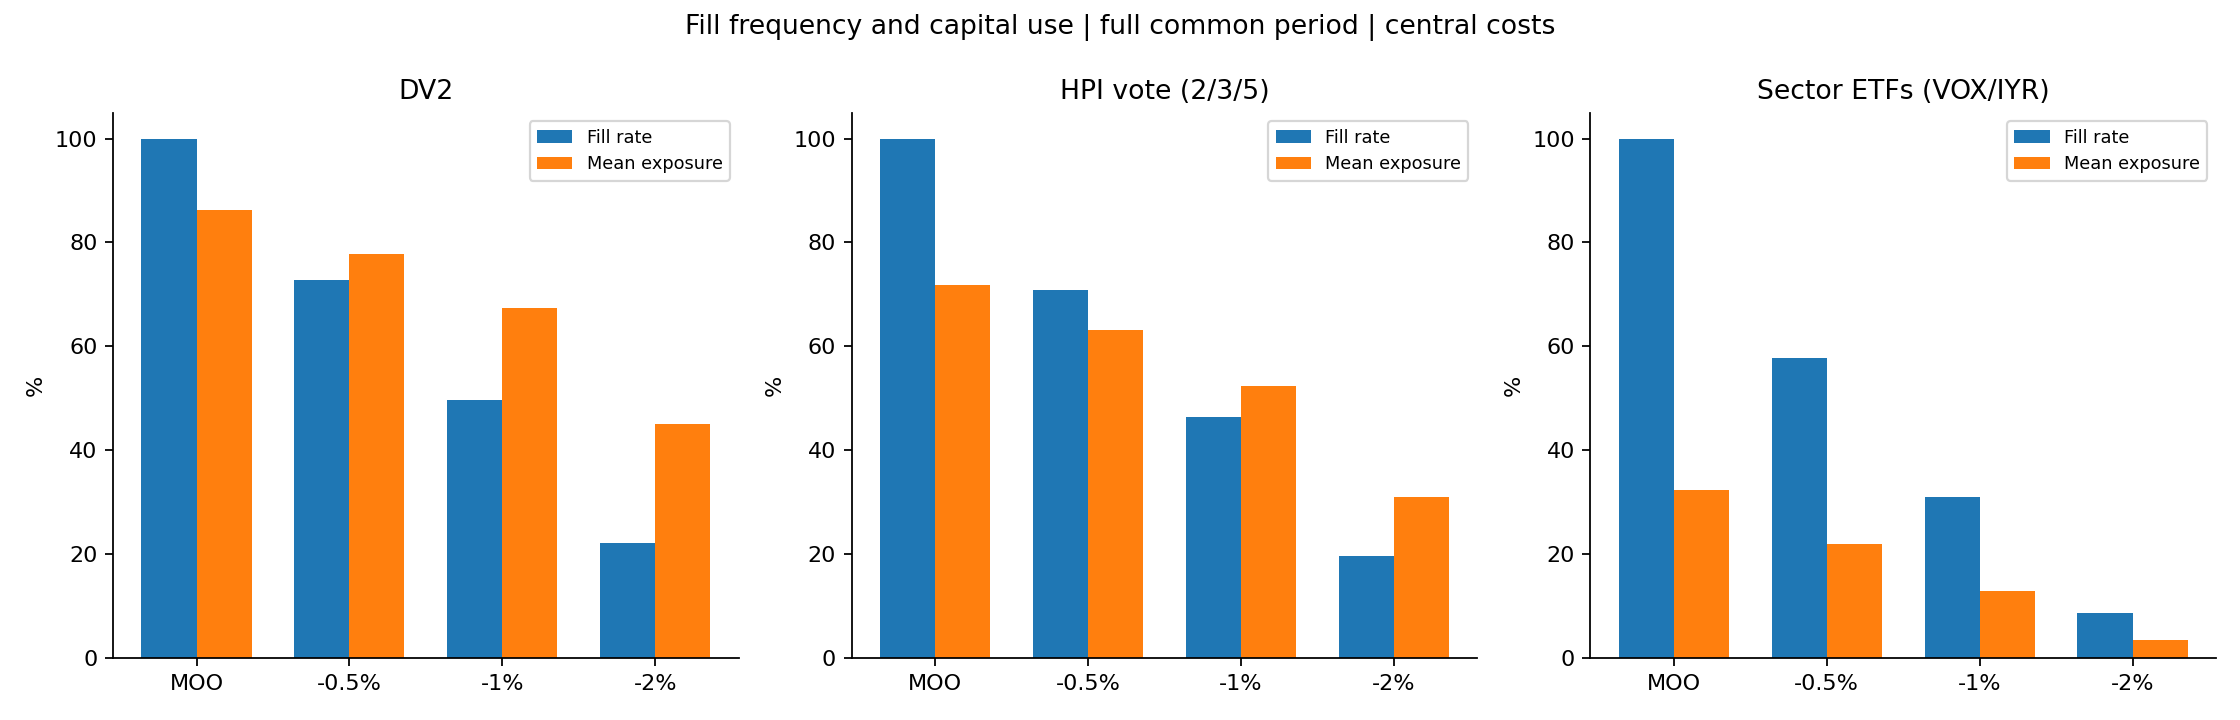

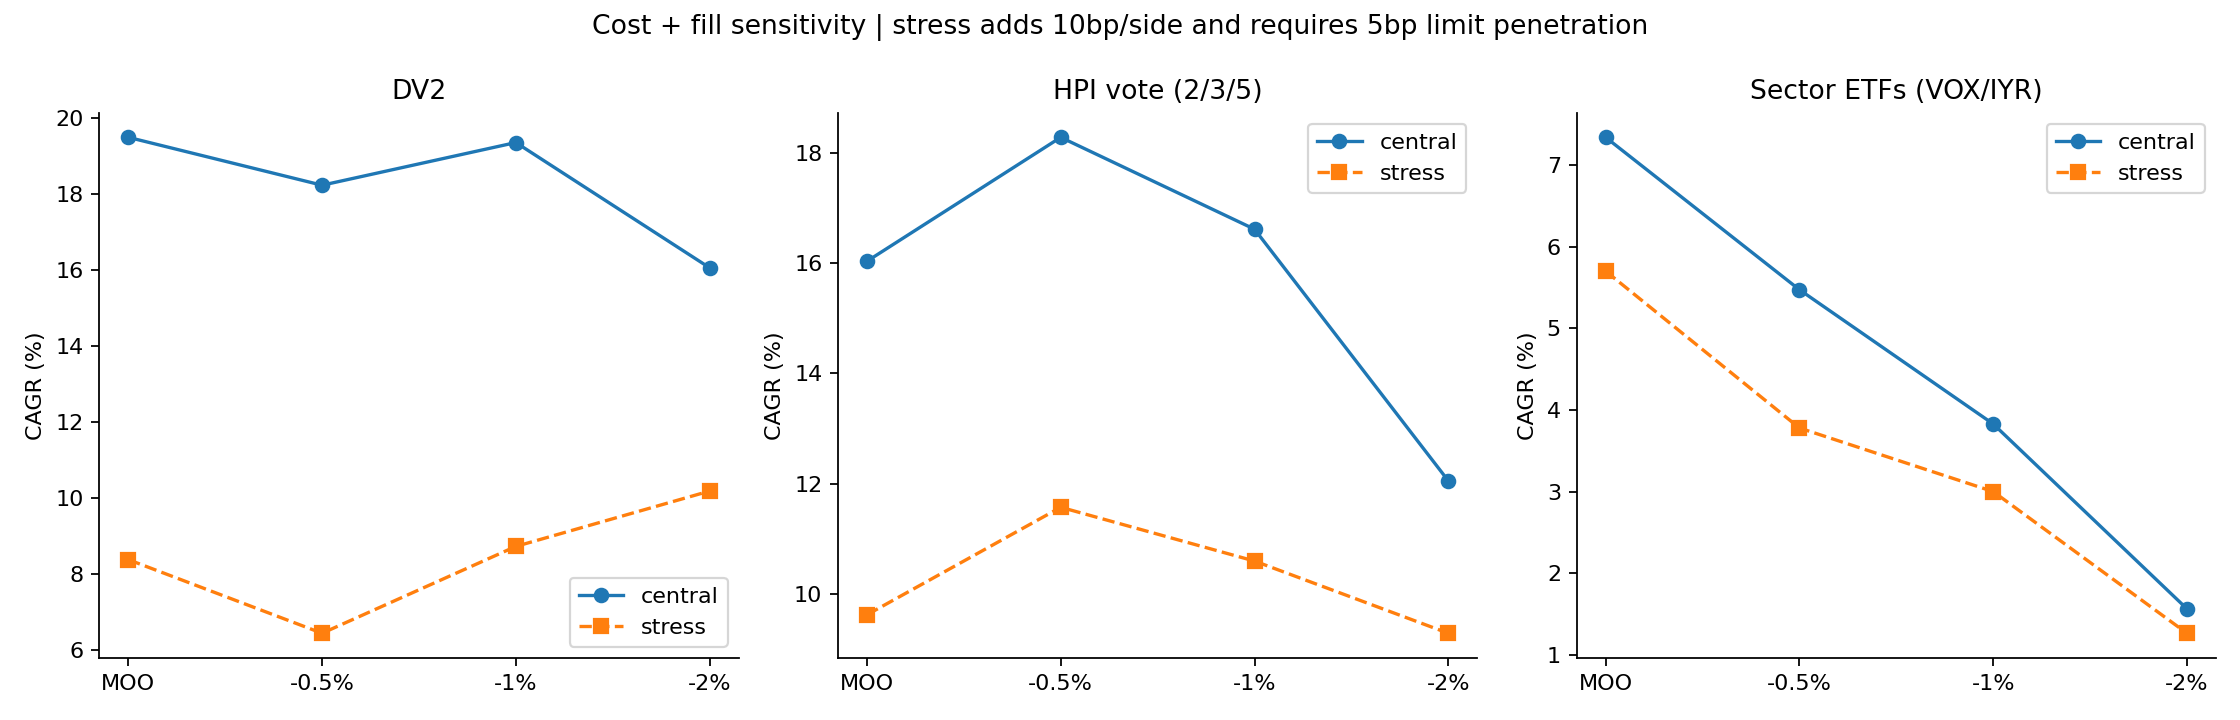

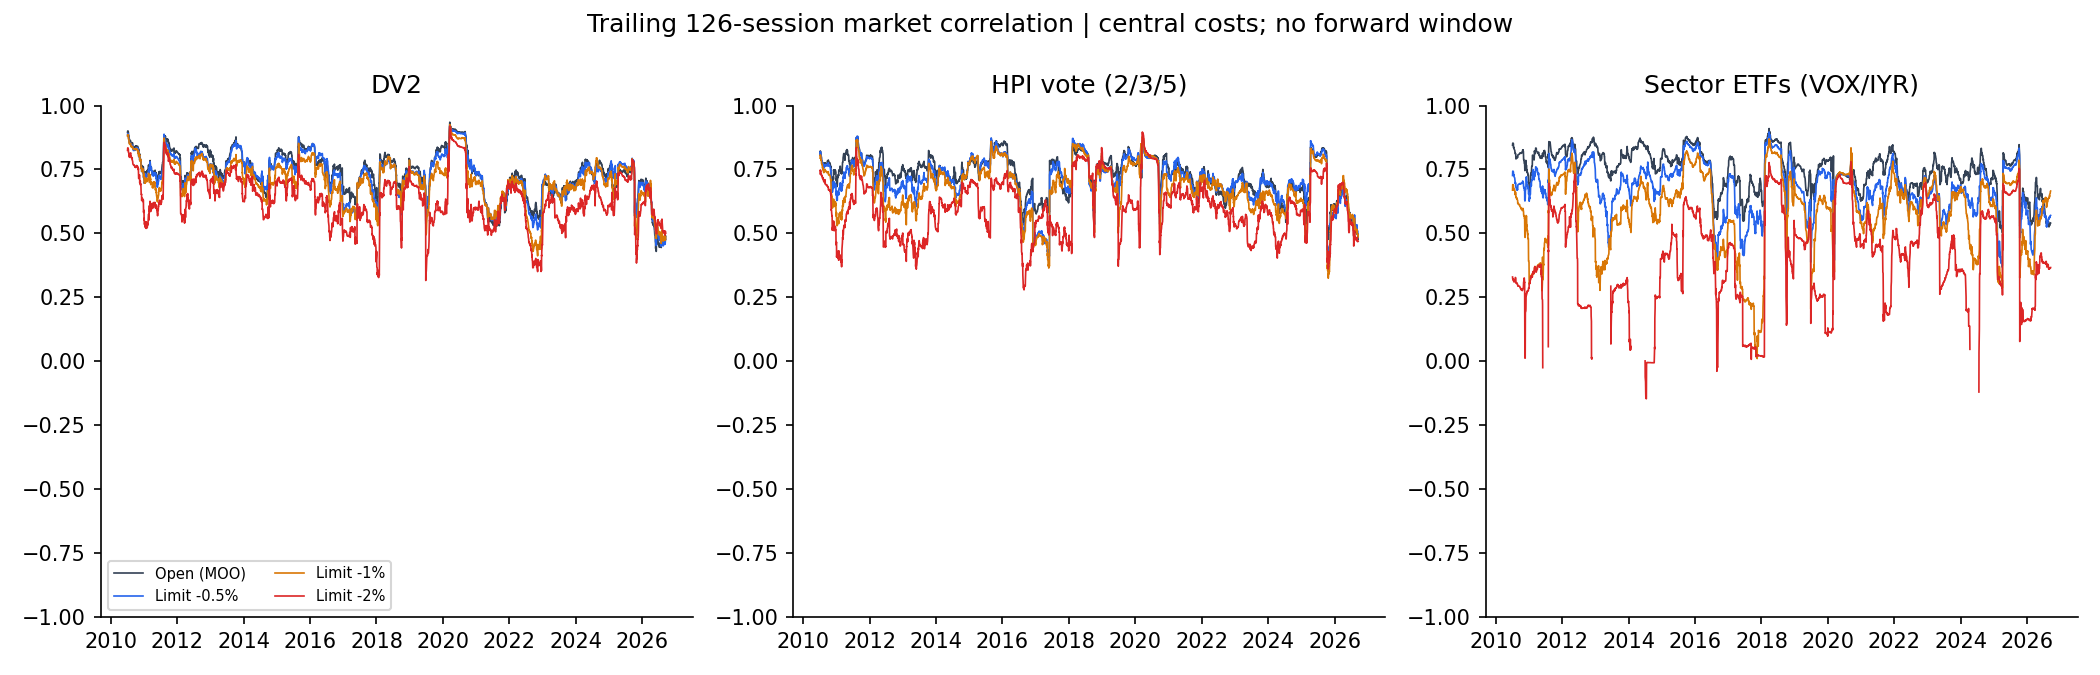

In [4]:
for chart_name_str in ('equity_drawdown.png','fills_exposure.png','cost_sensitivity.png','rolling_correlation.png'):
    display(Image(filename=str(study_path/'charts'/chart_name_str)))

## הכרעה

יש לקרוא את REPORT.md ואת מגבלות DV2 והתזמון. התאמה חשבונאית אינה ראיה למילוי בבורסה. המפרט, הקוד והנתונים קשורים בחתימות; כל 24 החלופות מוצגות.